### 패키지 로드 및 데이터 불러오기

In [1]:
from hossam import load_data
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

from pandas import DataFrame, get_dummies
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np


from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.spatial import ConvexHull

from kneed import KneeLocator

from scipy.stats import normaltest

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import silhouette_samples, silhouette_score
my_dpi = 200


In [2]:
from sklearn.preprocessing import MinMaxScaler

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from scipy.spatial import ConvexHull
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.spatial import ConvexHull

my_dpi = 200


In [3]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [4]:
origin = load_data('customer')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

다음의 데이터는 어느 백화점의 고객에 대한 성별,나이,연수입,지출점수를 조사한 가상 데이터

===== 데이터 크기 확인 =====
데이터셋 크기: (200, 5)
열 개수: 5
행 개수: 200

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   고객ID    200 non-null    int64 
 1   성별      200 non-null    object
 2   나이      200 non-null    int64 
 3   연수입     200 non-null    int64 
 4   지출점수    200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


,고객ID,성별,나이,연수입,지출점수
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 데이터 탐색 및 전처리<br>
1.인덱스 지정<br>
2.정규분포 여부 확인<br>
3.정규분포를 따르지 않는 데이터에 대해서 표준화 적용<br>
4.명목형 변수 인코딩

In [5]:
df = origin.copy("고객ID")
df.head()


,고객ID,성별,나이,연수입,지출점수
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:

fields = [ "나이", "연수입", "지출점수" ]

for f in fields:

    # 정규성 검정
    stat, p = normaltest(origin[f])
    alpha = 0.05

    print(f"\n==== {f} 정규성 검정 ====")
    print(f"stat = {stat}, p = {p}")

    if p > alpha:
        print(f"{f}는 정규분포를 따릅니다 (귀무가설 채택)")
    else:
        print(f"{f}는 정규분포를 따르지 않습니다 (귀무가설 기각)")



==== 나이 정규성 검정 ====
stat = 15.577514003752057, p = 0.000414367622180182
나이는 정규분포를 따르지 않습니다 (귀무가설 기각)

==== 연수입 정규성 검정 ====
stat = 3.5109953115353187, p = 0.17282121541298148
연수입는 정규분포를 따릅니다 (귀무가설 채택)

==== 지출점수 정규성 검정 ====
stat = 16.302230221326983, p = 0.0002884135672001835
지출점수는 정규분포를 따르지 않습니다 (귀무가설 기각)


In [7]:
scale_df = df[["나이", "연수입", "지출점수"]].copy()
scaler = StandardScaler()
sdf = DataFrame(
    scaler.fit_transform(scale_df),columns = scale_df.columns, index = scale_df.index
)

sdf.insert(0,"성별", df["성별"])
sdf

,성별,나이,연수입,지출점수
0,Male,-1.424569,-1.738999,-0.434801
1,Male,-1.281035,-1.738999,1.195704
2,Female,-1.352802,-1.700830,-1.715913
3,Female,-1.137502,-1.700830,1.040418
4,Female,-0.563369,-1.662660,-0.395980
...,...,...,...,...
195,Female,-0.276302,2.268791,1.118061
196,Female,0.441365,2.497807,-0.861839
197,Male,-0.491602,2.497807,0.923953
198,Male,-0.491602,2.917671,-1.250054


In [8]:
df_dummies = get_dummies(sdf, columns=["성별"], dtype="int", drop_first=False)
df_dummies.head()

,나이,연수입,지출점수,성별_Female,성별_Male
0,-1.424569,-1.738999,-0.434801,0,1
1,-1.281035,-1.738999,1.195704,0,1
2,-1.352802,-1.700830,-1.715913,1,0
3,-1.137502,-1.700830,1.040418,1,0
4,-0.563369,-1.662660,-0.395980,1,0


## 엘보우 포인트 구하기<br>
1.적절한 범위 내에서 이너셔 값 생성<br>
2.최적의 k값(엘보우 포인트) 도출<br>
3.시각화 확인

In [9]:
# k 후보 리스트
klist = list(range(3, 11))

# inertia 값을 저장할 리스트
inertia = []

for k in klist:
    estimator = KMeans(
        n_clusters=k,
        random_state=52
    )

    estimator.fit(X=df_dummies)
    inertia.append(estimator.inertia_)

# 결과 확인
inertia


[393.5986115835211,
 304.3074053388816,
 284.3453955595961,
 245.03129918573325,
 237.7227000085023,
 197.75874820044876,
 173.3303339679523,
 163.9166081964125]

In [10]:
kl = KneeLocator(klist,inertia,curve="convex", direction="decreasing",S=0.1)
best_k = kl.elbow
best_y = kl.elbow_y
print("found elbow:",  best_k)
print("found y:, best_y")

found elbow: 4
found y:, best_y


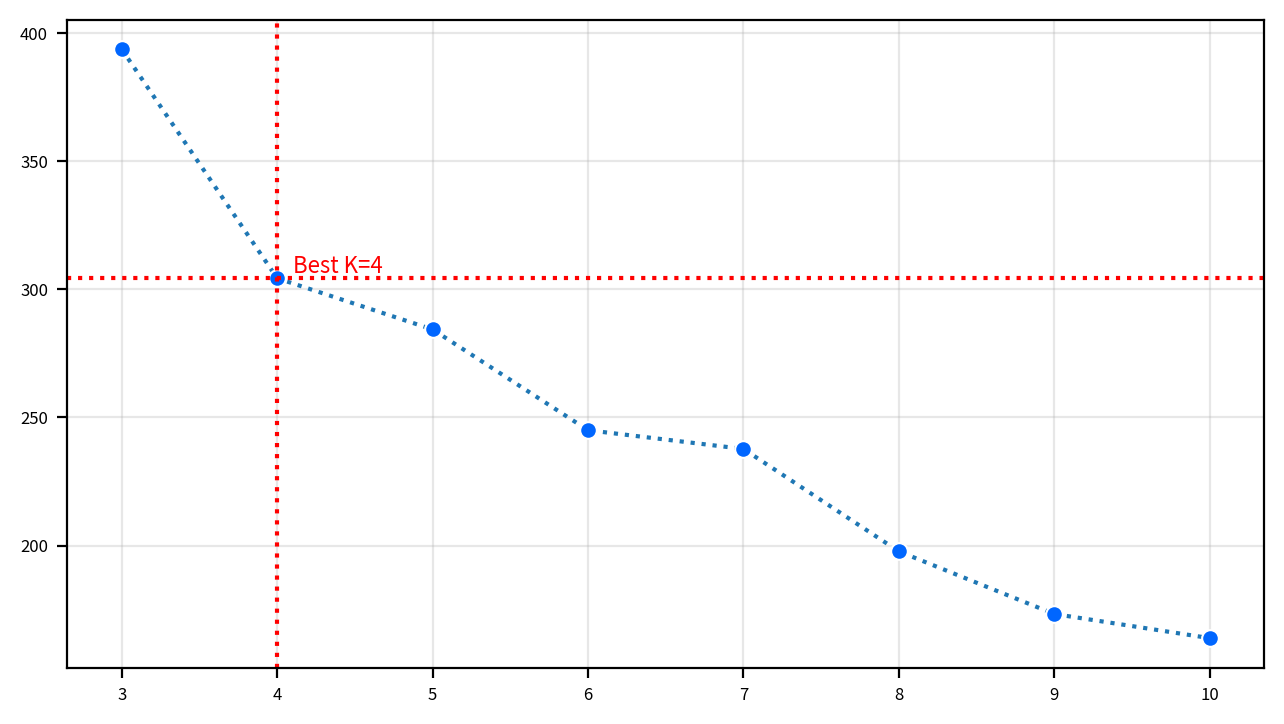

In [11]:
# -------------------------------
# 그래프 초기화
# -------------------------------
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=figsize,
    dpi=my_dpi
)


# -------------------------------
# Line Plot
# -------------------------------
sb.lineplot(
    x=klist,
    y=inertia,
    linestyle=":",
    marker="o",
    markerfacecolor="#0066ff",
    markeredgecolor="#ffffff"
)


# -------------------------------
# 엘보우 포인트 표시
# -------------------------------
if best_k is not None:

    ax.axvline(
        x=best_k,
        color="red",
        linestyle=":"
    )

    ax.axhline(
        y=best_y,
        color="red",
        linestyle=":"
    )

    ax.text(
        best_k + 0.1,
        best_y + 0.1,
        f"Best K={best_k}",
        fontsize=8,
        ha="left",
        va="bottom",
        color="r"
    )


# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
plt.close()


## 엘보우 포인트 검증(실루엣 스코어)<br>
1.실루엣 스코어 시각화 함수 정의<br>
2.군집수별 실루엣 스코어 확인

In [12]:
def visualize_silhouette(estimator, X_features):

    # -------------------------------
    # Figure 생성
    # -------------------------------
    fig, (ax1, ax2) = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(18, 7)
    )

    # -------------------------------
    # Silhouette Score 계산
    # -------------------------------
    sil_avg = silhouette_score(
        X=X_features,
        labels=estimator.labels_
    )

    sil_values = silhouette_samples(
        X=X_features,
        labels=estimator.labels_
    )

    # -------------------------------
    # Silhouette Plot (좌측)
    # -------------------------------
    y_lower = 10

    plt.suptitle(
        "Number of Cluster : "
        + str(estimator.n_clusters)
        + ", Silhouette Score : "
        + str(round(sil_avg, 3))
    )

    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_features) + (estimator.n_clusters + 1) * 10])
    ax1.set_yticks([])     # Clear the y-axis labels / ticks
    ax1.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax1.grid(True)

    # -------------------------------
    # 클러스터별 Silhouette 영역
    # -------------------------------
    for i in range(estimator.n_clusters):

        ith_cluster_sil_values = sil_values[
            estimator.labels_ == i
        ]
        ith_cluster_sil_values.sort()

        size_cluster_i = ith_cluster_sil_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(
            float(i) / estimator.n_clusters
        )

        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_sil_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )

        ax1.text(
            -0.05,
            y_lower + 0.5 * size_cluster_i,
            str(i)
        )

        y_lower = y_upper + 10

    # 평균 Silhouette 기준선
    ax1.axvline(
        x=sil_avg,
        color="red",
        linestyle="--"
    )

    # -------------------------------
    # 실제 클러스터 산점도 (우측)
    # -------------------------------
    colors = cm.nipy_spectral(
        estimator.labels_.astype(float) / estimator.n_clusters
    )

    ax2.scatter(
        X_features[X_features.columns[0]],
        X_features[X_features.columns[1]],
        marker="o",
        s=30,
        lw=0,
        alpha=0.7,
        c=colors,
        edgecolor="k"
    )

    # -------------------------------
    # 클러스터 중심점 표시
    # -------------------------------
    centers = estimator.cluster_centers_

    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k"
    )

    # 중심점 강조 표시
    for i, c in enumerate(centers):
        ax2.scatter(
            c[0],
            c[1],
            marker=f"${i}$",
            s=50,
            edgecolor="k"
        )

    ax2.set_title("The visualization of the clustered data")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()


In [13]:
# 시각화용 최소 군집 수 (분석 구간으로 결정)
klist = list(range(3, 11))

silhouette = []   # 실루엣 스코어 저장 리스트

for k in klist:
    estimator = KMeans(
        n_clusters=k,
        random_state=52
    )

    estimator.fit(X=df_dummies)

    cluster = estimator.predict(df_dummies)

    s_score = silhouette_score(
        X=df_dummies,
        labels=cluster
    )

    silhouette.append(s_score)

    # 시각화가 필요할 경우 사용
    # visualize_silhouette(estimator=estimator, X_features=df_encoded)


# 결과 DataFrame 생성
silhouette_df = DataFrame(
    {
        "k": klist,
        "silhouette_score": silhouette
    }
)

silhouette_df


,k,silhouette_score
0,3,0.287876
1,4,0.318743
2,5,0.295763
3,6,0.309651
4,7,0.298297
5,8,0.313272
6,9,0.339913
7,10,0.336890


최종 모형<br>
1.k가 6일 때의 군집<br>
2.군집 결과 시각화


In [14]:
# -------------------------------
# KMeans 학습 및 클러스터 할당
# -------------------------------
estimator = KMeans(
    n_clusters=6,
    random_state=52
)

estimator.fit(X=df_dummies)
clusters = estimator.predict(df_dummies)

cdf = df_dummies.copy()
cdf["ClusterID"] = clusters

cdf.head()


,나이,연수입,지출점수,성별_Female,성별_Male,ClusterID
0,-1.424569,-1.738999,-0.434801,0,1,1
1,-1.281035,-1.738999,1.195704,0,1,5
2,-1.352802,-1.700830,-1.715913,1,0,1
3,-1.137502,-1.700830,1.040418,1,0,5
4,-0.563369,-1.662660,-0.395980,1,0,1


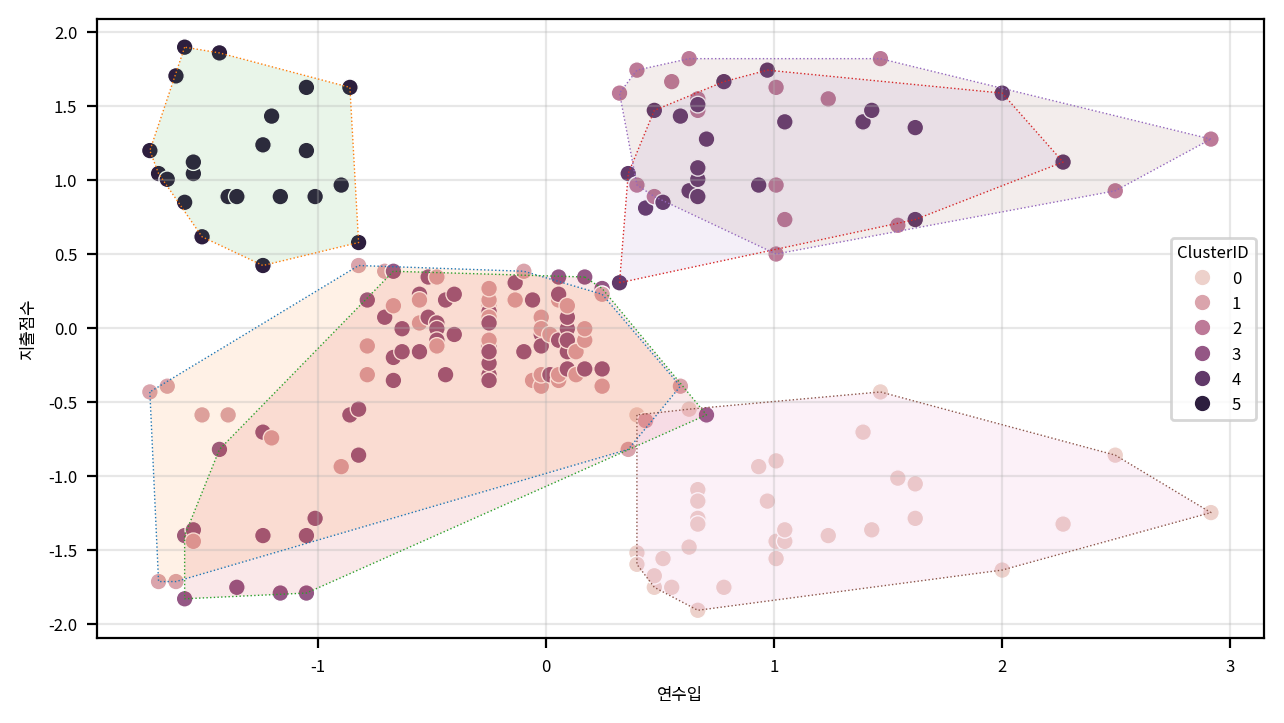

In [15]:
# -------------------------------
# 시각화용 데이터 설정
# -------------------------------
vdf = cdf.copy()

hue_field = "ClusterID"
x_field = "연수입"
y_field = "지출점수"


# -------------------------------
# 그래프 초기화
# -------------------------------
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=figsize,
    dpi=my_dpi
)


# -------------------------------
# 데이터 산점도
# -------------------------------
sb.scatterplot(
    data=vdf,
    x=x_field,
    y=y_field,
    hue=hue_field
)


# -------------------------------
# 군집별 Convex Hull
# -------------------------------
for c in vdf[hue_field].unique():

    # 군집별 데이터 분리
    df_c = vdf.loc[
        vdf[hue_field] == c,
        [x_field, y_field]
    ]

    try:
        # 외곽선 계산
        hull = ConvexHull(df_c)

        # 마지막 점과 첫 점 연결
        points = np.append(
            hull.vertices,
            hull.vertices[0]
        )

        # 외곽선 그리기
        ax.plot(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            linewidth=0.5,
            linestyle=":"
        )

        # 영역 채우기
        ax.fill(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            alpha=0.1
        )

    except Exception:
        pass


# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
plt.close()


In [16]:
pdf = origin.copy()
pdf["ClusterID"]=clusters
pdf.drop("고객ID", axis=1, inplace=True)
pdf.head()

,성별,나이,연수입,지출점수,ClusterID
0,Male,19,15,39,1
1,Male,21,15,81,5
2,Female,20,16,6,1
3,Female,23,16,77,5
4,Female,31,17,40,1


In [17]:
persona_list = []

for i in range(best_k):

    # 클러스터별 데이터 분리
    cluster_data = pdf[pdf["ClusterID"] == i]
    # display(cluster_data.head())
    # continue

    persona_item = {"Cluster": i}

    for column in cluster_data.columns:

        # print(column)

        if column == "ClusterID":
            continue

        elif column == "성별":
            # 범주형 변수: 최빈값 사용
            persona_item[column] = (
                cluster_data[column]
                .value_counts()
                .idxmax()
            )

        else:
            # 수치형 변수: 정규성 검정 후 평균/중앙값 선택
            stat, p = normaltest(cluster_data[column])
            alpha = 0.05

            if p > alpha:
                mean_value = cluster_data[column].mean()
                persona_item[column] = mean_value
            else:
                median_value = cluster_data[column].median()
                persona_item[column] = median_value

    persona_list.append(persona_item)


# 결과 DataFrame 생성 및 정렬
persona_df = DataFrame(persona_list)

persona_df = (
    persona_df
    .sort_values(by="Cluster")
    .reset_index(drop=True)
)

persona_df


,Cluster,성별,나이,연수입,지출점수
0,0,Male,41.264706,85.500000,16.764706
1,1,Female,27.000000,49.586957,47.000000
2,2,Male,33.277778,82.500000,82.666667
3,3,Female,53.500000,48.482759,46.000000
